In [1]:
import math

import torch
from torch import nn
from d2l import torch as d2l

In [2]:
# Position-Wise Feed-Forward Network
class PositionWiseFFN(nn.Module):
    
    def __init__(
        self,
        ffn_num_hiddens: int,
        ffn_num_outputs: int,
    ) -> None:
        super().__init__()
        
        self.dense1 = nn.LazyLinear(
            out_features=ffn_num_hiddens,
        )
        
        self.relu = nn.ReLU()
        
        self.dense2 = nn.LazyLinear(
            out_features=ffn_num_outputs
        )
        
    def forward(
        self,
        X: torch.Tensor,
    ) -> torch.Tensor:
        
        return self.dense2(
            self.relu(
                self.dense1(X)
            )
        )
        
        
# AddNorm
class AddNorm(nn.Module):
    
    def __init__(
        self,
        norm_shape: int,
        dropout: float,
    ) -> None:
        super().__init__()

        self.dropout = nn.Dropout(
            p=dropout,
        )

        self.layer_norm = nn.LayerNorm(
            normalized_shape=norm_shape,
        )
        
    def forward(
        self,
        X: torch.Tensor,
        Y: torch.Tensor,
    ) -> torch.Tensor:
        
        if X.shape != Y.shape:
            raise ValueError(
                "X and Y must have the same shape."
            )

        return self.layer_norm(
            X + self.dropout(Y)
        )

In [3]:
# Decoder State Type

DecoderState = tuple[
    torch.Tensor,               # Encoder Output
    torch.Tensor | None,        # Encoder Valid Length
    list[torch.Tensor | None],  # Block별 Decoder cache
]

In [4]:
# Transformer Decoder Block

class TransformerDecoderBlock(nn.Module):
    
    def __init__(
        self,
        num_hiddens: int,
        ffn_num_hiddens: int,
        num_heads: int,
        dropout: float,
        block_index: int,
    ) -> None:
        super().__init__()
        
        self.block_index = block_index
        
        # Masked Decoder Self-Attention
        self.self_attention = d2l.MultiHeadAttention(
            num_hiddens=num_hiddens,
            num_heads=num_heads,
            dropout=dropout,
        )
        
        self.add_norm1 = AddNorm(
            norm_shape=num_hiddens,
            dropout=dropout,
        )
        
        # Encoder-Decoder Attention
        self.cross_attention = d2l.MultiHeadAttention(
            num_hiddens=num_hiddens,
            num_heads=num_heads,
            dropout=dropout,
        )
        
        self.add_norm2 = AddNorm(
            norm_shape=num_hiddens,
            dropout=dropout,
        )
        
        self.ffn = PositionWiseFFN(
            ffn_num_hiddens=ffn_num_hiddens,
            ffn_num_outputs=num_hiddens,
        )
        
        self.add_norm3 = AddNorm(
            norm_shape=num_hiddens,
            dropout=dropout,
        )
        
        
    def forward(
        self,
        X: torch.Tensor,
        state: DecoderState,
    ) -> tuple[
        torch.Tensor,
        DecoderState,
    ]:
        
        (
            encoder_outputs,
            encoder_valid_lens,
            cache,
        ) = state

        cached_key_values = cache[
            self.block_index
        ]
        
        # Training: 
        # cache가 None이므로 현재 전체 Target Sequence를 사용
        if cached_key_values is None:
            key_values = X

        # Prediction:
        # 이전 step의 cache 뒤에 현재 token을 연결
        else: key_values = torch.cat(
            (
                cached_key_values,
                X,
            ),
            dim=1,
        )
        
        cache[
            self.block_index
        ] = key_values
        
        
        # Training에서는 전체 Target Sequence가 주어지므로
        # 미래 position을 가리는 Causal Mask가 필요하다.
        if self.training:
            
            (
                batch_size,
                num_steps,
                _,
            ) = X.shape
            
            # Shape: [B, T_tgt]
            decoder_valid_lens: (
                torch.Tensor | None
            ) = torch.arange(
                1,
                num_steps + 1,
                device=X.device,
            ).repeat(
                batch_size,
                1,
            )
            
        # Prediction에서는 cache에 미래 token이 존재하지 않는다.
        else:
            decoder_valid_lens = None
            
        
        
        # 1) Masked Decoder Self-Attention
        # Query : 현재 Decoder Input
        # Key   : 현재까지의 Decoder cache
        # Value : 현재까지의 Decoder cache
        self_attention_output = self.self_attention(
            queries=X,
            keys=key_values,
            values=key_values,
            valid_lens=decoder_valid_lens,
        )
        
        Y = self.add_norm1(
            X,
            self_attention_output,
        )
        
        # 2) Encoder–Decoder Attention
        # Query : Decoder의 중간 Output
        # Key   : Encoder Output
        # Value : Encoder Output
        cross_attention_output = self.cross_attention(
            queries=Y,
            keys=encoder_outputs,
            values=encoder_outputs,
            valid_lens=encoder_valid_lens,
        )
        
        Z = self.add_norm2(
            Y,
            cross_attention_output,
        )
        
        # 3) Position-Wise FFN
        return (
            self.add_norm3(
                Z,
                self.ffn(Z),
            ),
            state,
        )

In [5]:
# Transformer Decoder

class TransformerDecoder(d2l.AttentionDecoder):
    
    def __init__(
        self,
        vocab_size: int,
        num_hiddens: int,
        ffn_num_hiddens: int,
        num_heads: int,
        num_blocks: int,
        dropout: float,
    ) -> None:
        super().__init__() 
        
        self.num_hiddens = num_hiddens
        self.num_blocks = num_blocks

        # [B, T] -> [B, T, D]
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=num_hiddens,
        )
        
        self.positional_encoding = d2l.PositionalEncoding(
            num_hiddens=num_hiddens,
            dropout=dropout,
        )
        
        self.blocks = nn.Sequential(
            *[
                TransformerDecoderBlock(
                    num_hiddens=num_hiddens,
                    ffn_num_hiddens=ffn_num_hiddens,
                    num_heads=num_heads,
                    dropout=dropout,
                    block_index=block_index,
                )
                for block_index in range(
                    num_blocks
                )
            ]
        )
        
        # [B, T, D] -> [B, T, V]
        self.output_layer = nn.LazyLinear(
            out_features=vocab_size,
        )
        
        self._attention_weights: list[
            list[torch.Tensor]
        ] = [
            [],
            [],
        ]
        
        
        
    def init_state(
        self,
        encoder_outputs: torch.Tensor,
        encoder_valid_lens: torch.Tensor | None,
        *args: object,
    ) -> DecoderState:
        
        return (
            encoder_outputs,
            encoder_valid_lens,
            [
                None
                for _ in range(
                    self.num_blocks
                )
            ],
        )
        
        
    def forward(
        self,
        X: torch.Tensor,
        state: DecoderState,
    ) -> tuple[
        torch.Tensor,
        DecoderState,
    ]:
        # Token Embedding: [B, T] -> [B, T, D]
        X = (
            self.embedding(X)
            * math.sqrt(
                self.num_hiddens
            )
        )
        
        # Positional Encoding: Token 순서 정보 추가
        X = self.positional_encoding(X)
        
        
        self_attention_weights: list[
            torch.Tensor
        ] = []
        
        cross_attention_weights: list[
            torch.Tensor
        ] = []
        
        
        for block in self.blocks:
            if not isinstance(
                block,
                TransformerDecoderBlock,
            ):
                raise TypeError(
                    "Every decoder block must be "
                    "a TransformerDecoderBlock."
                )
            
            X, state = block(
                X,
                state,
            )
            
            self_weights = getattr(
                block.self_attention.attention,
                "attention_weights",
                None,
            )
            
            cross_weights = getattr(
                block.cross_attention.attention,
                "attention_weights",
                None,
            )
            
            if not isinstance(
                self_weights,
                torch.Tensor,
            ):
                raise RuntimeError(
                    "Decoder self-attention weights "
                    "were not computed."
                )
            
            if not isinstance(
                cross_weights,
                torch.Tensor,
            ):
                raise RuntimeError(
                    "Cross-attention weights "
                    "were not computed."
                )
            
            self_attention_weights.append(
                self_weights
            )
            
            cross_attention_weights.append(
                cross_weights
            )
        
        
        self._attention_weights = [
            self_attention_weights,
            cross_attention_weights,
        ]
        
        # 각 Target Position에서 vocab 전체의 Logit 계산
        logits = self.output_layer(X)
        
        return logits, state
    
    
    @property
    def attention_weights(
        self,
    ) -> list[list[torch.Tensor]]:
        
        return self._attention_weights

In [6]:
# English–French Machine Translation Dataset

batch_size = 128

data = d2l.MTFraEng(
    batch_size=batch_size,
)


# Transformer Hyperparameters

num_hiddens = 256
ffn_num_hiddens = 64

num_heads = 4
num_blocks = 2

dropout = 0.2
learning_rate = 0.001


# 이전 notebook에서 직접 구현한 Encoder와
# 동일한 D2L Transformer Encoder를 사용한다.
encoder = d2l.TransformerEncoder(
    vocab_size=len(
        data.src_vocab
    ),
    num_hiddens=num_hiddens,
    ffn_num_hiddens=ffn_num_hiddens,
    num_heads=num_heads,
    num_blks=num_blocks,
    dropout=dropout,
)


# 현재 notebook에서 직접 구현한 Decoder
decoder = TransformerDecoder(
    vocab_size=len(
        data.tgt_vocab
    ),
    num_hiddens=num_hiddens,
    ffn_num_hiddens=ffn_num_hiddens,
    num_heads=num_heads,
    num_blocks=num_blocks,
    dropout=dropout,
)


model = d2l.Seq2Seq(
    encoder=encoder,
    decoder=decoder,
    tgt_pad=data.tgt_vocab[
        "<pad>"
    ],
    lr=learning_rate,
)


device = d2l.try_gpu()

print(
    "Device:",
    device,
)

print(
    "Source vocabulary:",
    len(data.src_vocab),
)

print(
    "Target vocabulary:",
    len(data.tgt_vocab),
)

print(
    "Encoder blocks:",
    num_blocks,
)

print(
    "Decoder blocks:",
    num_blocks,
)

print(
    "Attention heads:",
    num_heads,
)

Device: cuda:0
Source vocabulary: 194
Target vocabulary: 214
Encoder blocks: 2
Decoder blocks: 2
Attention heads: 4


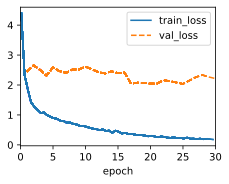

In [7]:
# Transformer Training

num_gpus = (
    1
    if torch.cuda.is_available()
    else 0
)

trainer = d2l.Trainer(
    max_epochs=30,
    gradient_clip_val=1,
    num_gpus=num_gpus,
)

trainer.fit(
    model,
    data,
)

In [8]:
# Translation과 BLEU Score

english_sentences = [
    "go .",
    "i lost .",
    "he's calm .",
    "i'm home .",
]

french_references = [
    "va !",
    "j'ai perdu .",
    "il est calme .",
    "je suis chez moi .",
]


predictions, _ = model.predict_step(
    data.build(
        english_sentences,
        french_references,
    ),
    device,
    data.num_steps,
)


for (
    english,
    french_reference,
    prediction,
) in zip(
    english_sentences,
    french_references,
    predictions,
):
    translated_tokens: list[str] = []
    
    predicted_tokens = (
        data.tgt_vocab.to_tokens(
            prediction
        )
    )
    
    for token in predicted_tokens:
        if token == "<eos>":
            break
        
        translated_tokens.append(
            token
        )
    
    translation = " ".join(
        translated_tokens
    )
    
    bleu_score = d2l.bleu(
        translation,
        french_reference,
        k=2,
    )
    
    print(
        f"{english:<12} "
        f"=> {translation:<25} "
        f"BLEU: {bleu_score:.3f}"
    )

go .         => va !                      BLEU: 1.000
i lost .     => j'ai perdu .              BLEU: 1.000
he's calm .  => il est mouillé .          BLEU: 0.658
i'm home .   => je suis chez moi .        BLEU: 1.000


In [9]:
# Translation 과정의 Attention Weight 수집

_, decoder_attention_steps = model.predict_step(
    data.build(
        [english_sentences[-1]],
        [french_references[-1]],
    ),
    device,
    data.num_steps,
    True,
)


raw_encoder_weights = getattr(
    model.encoder,
    "attention_weights",
    None,
)

if not isinstance(
    raw_encoder_weights,
    list,
):
    raise RuntimeError(
        "Encoder attention weights were not stored."
    )

if not all(
    isinstance(weights, torch.Tensor)
    for weights in raw_encoder_weights
):
    raise RuntimeError(
        "Invalid encoder attention weights."
    )


# [Block, Head, Source Query, Source Key]
encoder_attention_weights = torch.cat(
    raw_encoder_weights,
    dim=0,
).reshape(
    num_blocks,
    num_heads,
    data.num_steps,
    data.num_steps,
)

print(
    "Encoder attention:",
    tuple(encoder_attention_weights.shape),
)

print(
    "Prediction steps:",
    len(decoder_attention_steps),
)

d2l.check_shape(
    encoder_attention_weights,
    (
        num_blocks,
        num_heads,
        data.num_steps,
        data.num_steps,
    ),
)

Encoder attention: (2, 4, 9, 9)
Prediction steps: 9


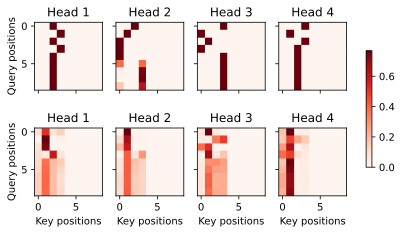

In [10]:
# Encoder Self-Attention Heatmap

d2l.show_heatmaps(
    encoder_attention_weights.cpu(),
    xlabel="Key positions",
    ylabel="Query positions",
    titles=[
        f"Head {head_index + 1}"
        for head_index in range(num_heads)
    ],
    figsize=(7, 3.5),
)

In [11]:
# Decoder Attention Weight 정리

# [Block, Head, Target Query, Target Key]
decoder_self_attention = torch.zeros(
    (
        num_blocks,
        num_heads,
        data.num_steps,
        data.num_steps,
    )
)

# [Block, Head, Target Query, Source Key]
decoder_cross_attention = torch.zeros(
    (
        num_blocks,
        num_heads,
        data.num_steps,
        data.num_steps,
    )
)


for query_position, step_attention in enumerate(
    decoder_attention_steps
):
    (
        self_attention_by_block,
        cross_attention_by_block,
    ) = step_attention

    for block_index in range(num_blocks):
        raw_self_attention = self_attention_by_block[
            block_index
        ]
        raw_cross_attention = cross_attention_by_block[
            block_index
        ]

        if not isinstance(
            raw_self_attention,
            torch.Tensor,
        ):
            raise RuntimeError(
                "Invalid decoder self-attention."
            )

        if not isinstance(
            raw_cross_attention,
            torch.Tensor,
        ):
            raise RuntimeError(
                "Invalid cross-attention."
            )

        current_target_length = raw_self_attention.shape[-1]
        current_source_length = raw_cross_attention.shape[-1]

        decoder_self_attention[
            block_index,
            :,
            query_position,
            :current_target_length,
        ] = raw_self_attention[:, 0, :].detach().cpu()

        decoder_cross_attention[
            block_index,
            :,
            query_position,
            :current_source_length,
        ] = raw_cross_attention[:, 0, :].detach().cpu()


print(
    "Decoder self-attention:",
    tuple(decoder_self_attention.shape),
)

print(
    "Encoder-decoder attention:",
    tuple(decoder_cross_attention.shape),
)

d2l.check_shape(
    decoder_self_attention,
    (
        num_blocks,
        num_heads,
        data.num_steps,
        data.num_steps,
    ),
)

d2l.check_shape(
    decoder_cross_attention,
    (
        num_blocks,
        num_heads,
        data.num_steps,
        data.num_steps,
    ),
)

Decoder self-attention: (2, 4, 9, 9)
Encoder-decoder attention: (2, 4, 9, 9)


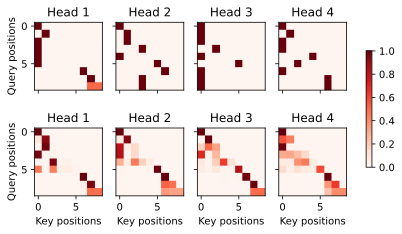

In [12]:
# Decoder Self-Attention Heatmap

d2l.show_heatmaps(
    decoder_self_attention,
    xlabel="Key positions",
    ylabel="Query positions",
    titles=[
        f"Head {head_index + 1}"
        for head_index in range(num_heads)
    ],
    figsize=(7, 3.5),
)

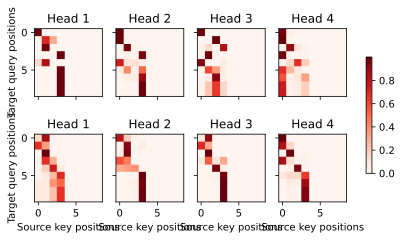

In [13]:
# Encoder-Decoder Attention Heatmap

d2l.show_heatmaps(
    decoder_cross_attention,
    xlabel="Source key positions",
    ylabel="Target query positions",
    titles=[
        f"Head {head_index + 1}"
        for head_index in range(num_heads)
    ],
    figsize=(7, 3.5),
)